# Heart Disease Prediction with Deep Learning

## Project Overview

Heart disease is one of the leading causes of death globally. Early and accurate prediction of heart disease risk using patient clinical data can significantly aid medical decision-making.

In this project, we build a **feedforward neural network (FNN)** using TensorFlow/Keras to predict the **presence or absence of heart disease** based on patient clinical features such as age, cholesterol levels, resting blood pressure, and more.

### Dataset
We use the **Cleveland Heart Disease Dataset**, originally from the UCI Machine Learning Repository, accessed via Kaggle. It contains **303 patient records** with **13 clinical features** and a binary target variable.

### Objectives
- Perform exploratory data analysis (EDA) on clinical features
- Preprocess and normalize the data for neural network training
- Build, train, and evaluate a feedforward neural network
- Interpret model performance using clinically relevant metrics (Accuracy, AUC-ROC, Confusion Matrix)

### Tools and Libraries
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `TensorFlow / Keras`

In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.20.0
All libraries loaded successfully


## Loading and Inspecting the Dataset

 We load the Cleveland Heart Disease Dataset directly from a public URL and perform an initial inspection to understand its structure, feature types, and any data quality issues such as missing values.

The dataset contains 13 input features and 1 target column. The original target variable has values from 0 to 4, where 0 means no heart disease and values 1–4 indicate presence of heart disease. We convert this into a **binary classification problem**: 0 (no disease) vs 1 (disease present).

In [2]:
# Load the dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=column_names, na_values="?")

# Convert target to binary: 0 = no disease, 1 = disease
df["target"] = (df["target"] > 0).astype(int)

# Initial inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["target"].value_counts())

Shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values pe

### Observations

The dataset loaded cleanly with **303 records and 14 columns** (13 features + target). All features are stored as floats, which is expected given the mix of continuous and encoded categorical variables.

Two columns have missing values: `ca` (4 missing) and `thal` (2 missing). Given the small number, these rows will be dropped rather than imputed, as they represent less than 2% of the data and imputing clinical measurements could introduce noise.

The target distribution is reasonably balanced — **164 cases with no disease (54%) and 139 with disease (46%)** — so there is no significant class imbalance that would require special handling such as oversampling or class weighting.

## Exploratory Data Analysis

Before preprocessing and modeling, it is important to understand the distributions of key features and how they relate to the target variable. The plots below cover the distribution of age, the breakdown of disease presence by sex, the correlation structure across all features, and the distributions of the three most clinically relevant continuous features — cholesterol, resting blood pressure, and maximum heart rate — split by target class.

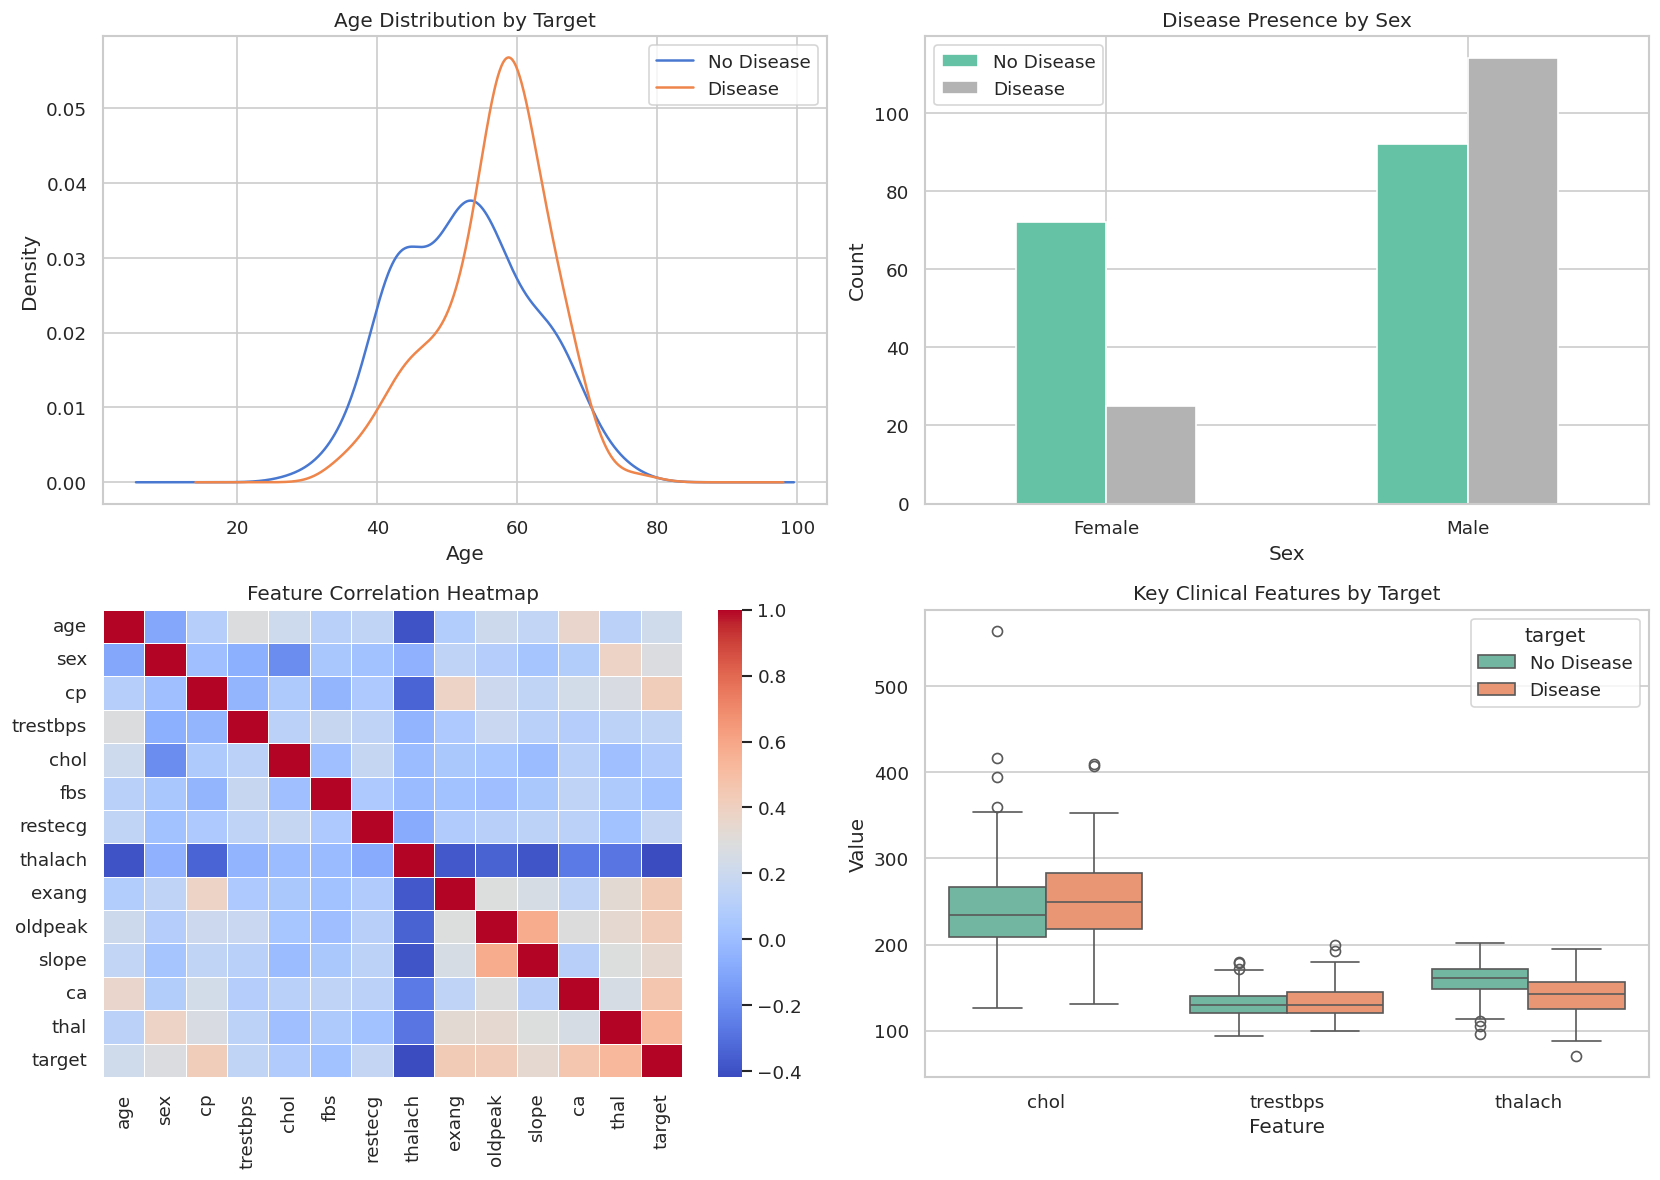

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution by target
axes[0, 0].set_title("Age Distribution by Target")
for label, group in df.groupby("target"):
    group["age"].plot.kde(ax=axes[0, 0],
                          label="No Disease" if label == 0 else "Disease")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# Disease count by sex
axes[0, 1].set_title("Disease Presence by Sex")
sex_target = df.groupby(["sex", "target"]).size().unstack()
sex_target.index = ["Female", "Male"]
sex_target.columns = ["No Disease", "Disease"]
sex_target.plot(kind="bar", ax=axes[0, 1], rot=0, colormap="Set2")
axes[0, 1].set_xlabel("Sex")
axes[0, 1].set_ylabel("Count")

# Correlation heatmap
axes[1, 0].set_title("Feature Correlation Heatmap")
corr = df.corr()
sns.heatmap(corr, ax=axes[1, 0], annot=False, cmap="coolwarm", linewidths=0.5)

# Box plots for key continuous features by target
df_melt = df[["chol", "trestbps", "thalach", "target"]].melt(
    id_vars="target",
    var_name="Feature",
    value_name="Value"
)
df_melt["target"] = df_melt["target"].map({0: "No Disease", 1: "Disease"})
sns.boxplot(data=df_melt, x="Feature", y="Value", hue="target",
            ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Key Clinical Features by Target")

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches="tight")
plt.show()

### Analysis

**Age Distribution:** Patients with heart disease tend to cluster in a narrower age range, peaking around 55–60 years, while those without disease are more spread across younger ages. This suggests age is a relevant predictor, though not exclusively a late-life condition in this dataset.

**Disease Presence by Sex:** The male cohort dominates the dataset overall, and also accounts for the majority of disease cases. Among females, disease cases are considerably fewer, though the dataset's female representation is limited, so this gap should be interpreted with caution.

**Feature Correlation Heatmap:** No severe multicollinearity is present among the input features, which is favorable for training. The strongest correlations with the target are seen in `thalach` (negative) and `cp`, `ca`, `thal`, and `oldpeak` (positive), indicating these features are likely to carry the most predictive weight.

**Key Clinical Features by Target:** Cholesterol levels show considerable overlap between the two classes and several high outliers, making it a weaker standalone discriminator. Resting blood pressure is similarly overlapping. Maximum heart rate (`thalach`) shows the clearest separation — patients with disease tend to have a noticeably lower maximum heart rate — reinforcing what the correlation heatmap suggested.

## Data Preprocessing

Missing values in `ca` and `thal` are dropped, the features are separated from the target, and the data is split into training and test sets using an 80/20 ratio with stratification to preserve the class distribution in both splits.

All 13 input features are then standardized using `StandardScaler`. Standardization is applied by fitting exclusively on the training set and transforming both sets accordingly, ensuring no information from the test set leaks into the training process.

In [4]:
# Drop rows with missing values
df_clean = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df_clean.shape)

# Separate features and target
X = df_clean.drop(columns=["target"]).values
y = df_clean["target"].values

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training set size :", X_train.shape)
print("Test set size     :", X_test.shape)
print("Train target distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test target distribution :", dict(zip(*np.unique(y_test,  return_counts=True))))

Shape after dropping missing values: (297, 14)
Training set size : (237, 13)
Test set size     : (60, 13)
Train target distribution: {np.int64(0): np.int64(128), np.int64(1): np.int64(109)}
Test target distribution : {np.int64(0): np.int64(32), np.int64(1): np.int64(28)}


### Results

Dropping the 6 rows with missing values left **297 clean records**, a minimal loss from the original 303. The 80/20 split produced a training set of 237 samples and a test set of 60 samples.

Stratification worked as intended — both splits maintain a near-identical class ratio of roughly 54% no disease to 46% disease, consistent with the original dataset distribution. This ensures the model is trained and evaluated on representative class proportions.

## Building the Neural Network

The model is a feedforward neural network with two hidden layers. Given the relatively small size of the dataset (237 training samples with 13 features), a lightweight architecture is appropriate — a large network would be prone to overfitting here.

The first hidden layer has 64 neurons and the second has 32, both using ReLU activation. Batch normalization is applied after each hidden layer to stabilize training, and dropout layers with a rate of 0.3 are included to reduce overfitting. The output layer uses a single sigmoid neuron for binary classification.

The model is compiled with the Adam optimizer, binary cross-entropy loss, and accuracy as the tracked metric during training.

In [5]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 192 (768.00 B)

### Model Summary

The network has **3,393 total parameters**, of which 3,201 are trainable. This is intentionally compact — a model of this size is well-suited to a dataset of under 300 samples, keeping the risk of overfitting in check.

The 192 non-trainable parameters belong to the batch normalization layers, which maintain running statistics for mean and variance that are updated during training but are not optimized by backpropagation directly.

The progressive reduction in layer width from 64 to 32 to 1 neuron forces the network to compress its learned representation down to a single probability score, which is the appropriate structure for a binary classification output.

## Training the Model

The model is trained for up to 200 epochs with a batch size of 32. Two callbacks are used during training: early stopping and learning rate reduction on plateau.

Early stopping monitors the validation loss and halts training if it does not improve for 20 consecutive epochs, restoring the best weights seen during training. The learning rate scheduler reduces the learning rate by a factor of 0.5 if validation loss stagnates for 10 epochs, allowing the optimizer to make finer adjustments as training progresses.

A 20% validation split is carved out from the training data during fitting to monitor generalization at each epoch.

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training complete")
print("Best epoch stopped at:", len(history.history["loss"]), "epochs")

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.6614 - loss: 0.7109 - val_accuracy: 0.5417 - val_loss: 0.6707 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6720 - loss: 0.6158 - val_accuracy: 0.6250 - val_loss: 0.6543 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7143 - loss: 0.5879 - val_accuracy: 0.7083 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7831 - loss: 0.5107 - val_accuracy: 0.7083 - val_loss: 0.6301 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7884 - loss: 0.4719 - val_accuracy: 0.7292 - val_loss: 0.6200 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8042 - loss: 0.4427 - val_accuracy: 0.7292 - val_loss: 0.6129 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8413 - loss: 0.3834 - val_accuracy:

### Training Results

Training stopped at epoch 31, with early stopping restoring the best weights from **epoch 11**, where validation loss was at its lowest (0.5918). Beyond that point, the validation loss steadily increased while training accuracy continued to climb — a clear sign of overfitting setting in on a dataset of this size.

The learning rate scheduler triggered twice: at epoch 21 and epoch 31, halving the rate each time to 0.0005 and then 0.00025. Despite this, the validation loss did not recover, which confirmed that the model had already reached its best generalization point early in training.

Training accuracy reached as high as 89–90% in later epochs, but this is misleading given the diverging validation loss. The restored weights from epoch 11 represent the most honest snapshot of what the model actually learned to generalize.

## Visualizing Training History

Plotting the training and validation loss and accuracy curves over epochs gives a clear picture of how the model learned and where generalization began to break down. The vertical dashed line marks the epoch at which early stopping restored the best weights.

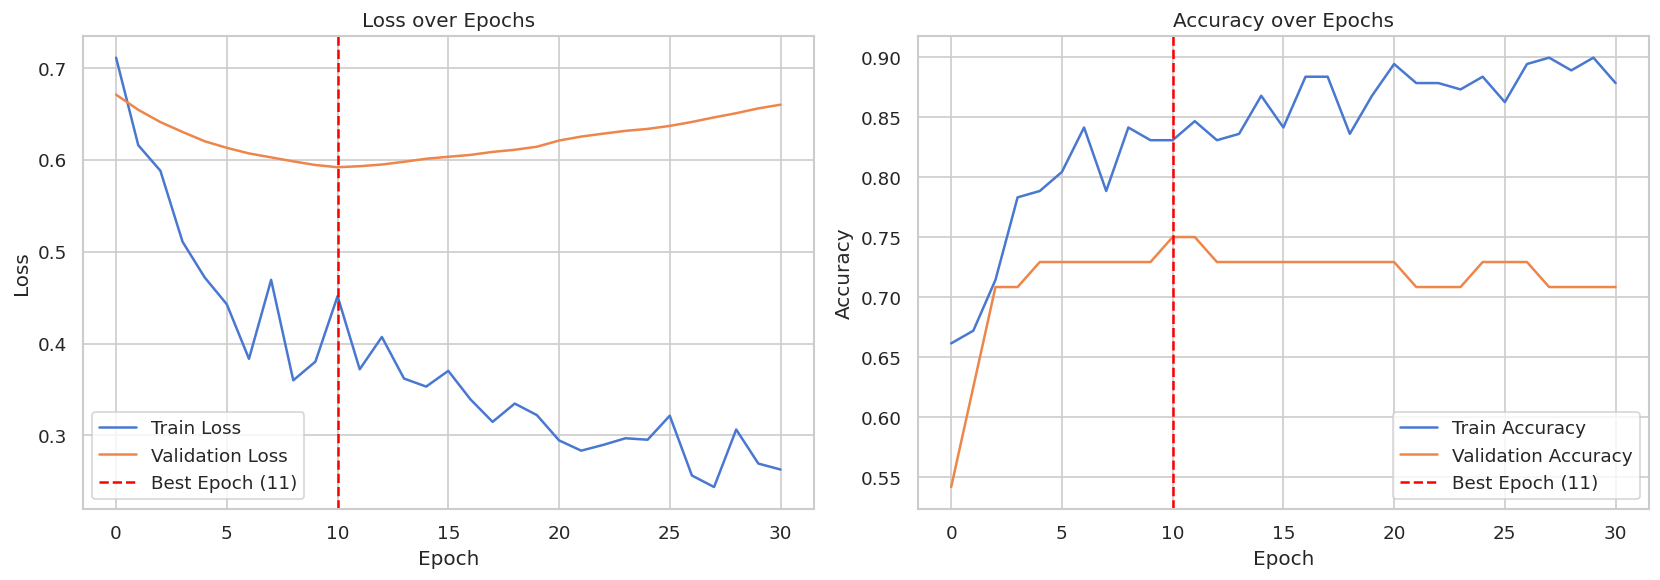

In [7]:
best_epoch = np.argmin(history.history["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].axvline(best_epoch, color="red", linestyle="--", label=f"Best Epoch ({best_epoch + 1})")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].axvline(best_epoch, color="red", linestyle="--", label=f"Best Epoch ({best_epoch + 1})")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", bbox_inches="tight")
plt.show()

### Analysis

The curves tell a consistent story. Training loss drops steadily and continuously throughout all 31 epochs, while validation loss reaches its minimum at **epoch 11** and begins climbing from there — the classic signature of a model that has started memorizing the training data rather than learning generalizable patterns.

The accuracy plot reinforces this. Validation accuracy plateaus at around 73–75% shortly after epoch 5 and never meaningfully improves, while training accuracy keeps rising toward 90%. The widening gap between the two curves after epoch 11 confirms that the early stopping callback made the right call in restoring weights from that point.

Given the small dataset size, this behavior is expected. The model extracted what signal it could from the available data, and the best epoch weights represent the point where that signal was most effectively captured before overfitting took over.

## Model Evaluation on the Test Set

With the best epoch weights restored, the model is evaluated on the held-out test set of 60 samples. The evaluation covers four aspects: overall loss and accuracy, a full classification report with precision, recall and F1-score per class, a confusion matrix, and the AUC-ROC curve. Together these give a complete picture of how the model performs across both classes rather than relying on a single summary metric.

Test Loss    : 0.4267
Test Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

AUC-ROC Score: 0.9297


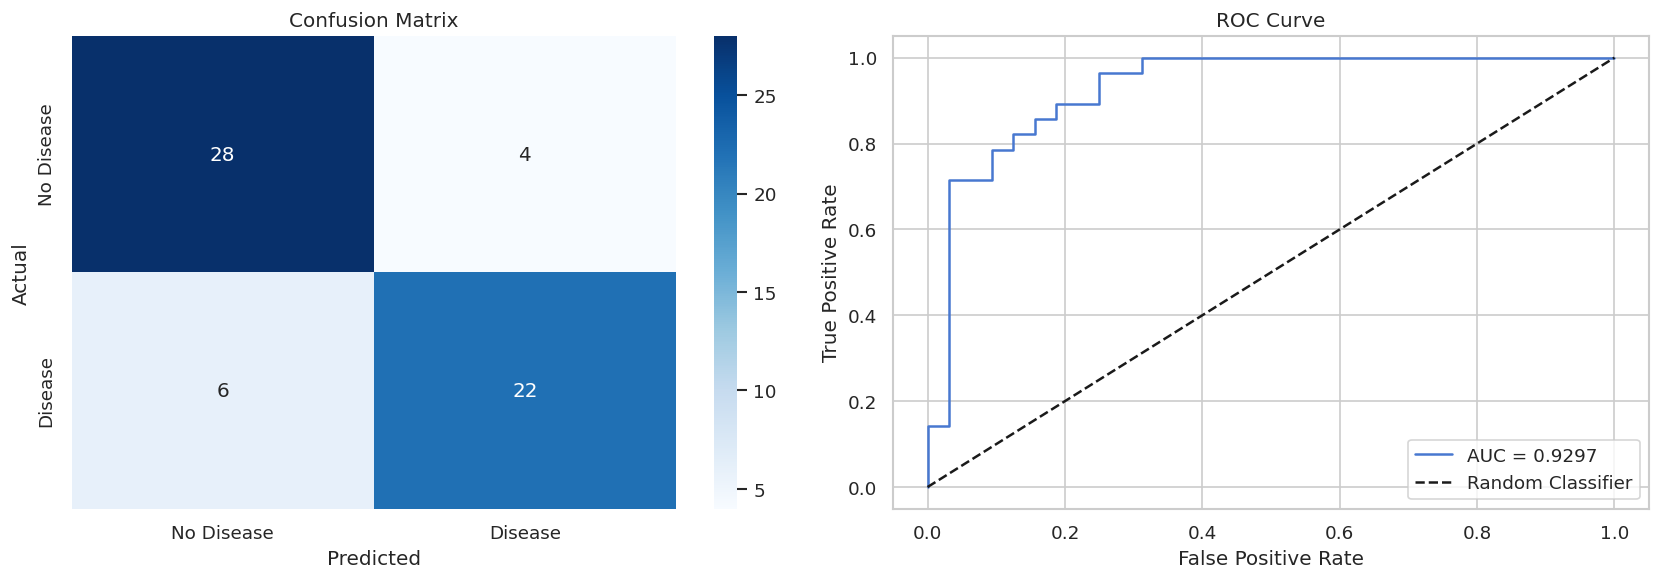

In [8]:
# Loss and accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No Disease", "Disease"]))

# AUC-ROC score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation.png", bbox_inches="tight")
plt.show()

### Results

The model achieved a **test accuracy of 83.3%** and an **AUC-ROC score of 0.9297** on the 60-sample held-out test set. The high AUC score indicates that the model has strong discriminative ability — it is well capable of separating disease from non-disease cases across different classification thresholds, even if the 0.5 threshold accuracy alone does not fully reflect this.

**Confusion Matrix:** Of the 32 actual no-disease cases, 28 were correctly identified and 4 were incorrectly flagged as disease (false positives). Of the 28 actual disease cases, 22 were correctly identified and 6 were missed (false negatives). In a clinical screening context, the 6 missed disease cases are the more consequential errors, as failing to flag a patient with heart disease carries greater risk than a false alarm.

**Classification Report:** Precision and recall are well balanced across both classes. The disease class achieved a precision of 0.85 and recall of 0.79, while the no-disease class reached a recall of 0.88. The macro average F1-score of 0.83 confirms that the model performs consistently across both classes rather than favouring the majority class.

**ROC Curve:** The curve rises steeply toward the top-left corner and stays well above the random classifier diagonal throughout, which is consistent with the 0.93 AUC score and confirms strong overall classification performance relative to the dataset size.